# Activation Patching the Choose Similar Entity Task

The goal is to find the entity among three who is most similar to a stated comparison entity.



## General Hypothesis

![General Hypothesis](images/choose_sim_ent.png)

So the question is whether a similar mlp and attention pattern exists in this task as exists in the connections task.

## Experimental Design

I will run activation patching.

Here, I will keep the set common, and patch on the subject int.

My goal is to visualize the indirect effects of the residual, mlp, and attention layers.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import json

import sys

sys.path.append("../")

##################################################################
os.environ["TOKENIZERS_PARALLELISM"] = "false"
os.environ["CUDA_VISIBLE_DEVICES"] = "0,1,2,3,4,5,6,7" #! NOTE: CHANGE TO 0,1 FOR VAST AI
##################################################################

import logging
from src.utils import logging_utils
from src.utils import env_utils

logger = logging.getLogger(__name__)

logging.basicConfig(
    level=logging.DEBUG,
    format=logging_utils.DEFAULT_FORMAT,
    datefmt=logging_utils.DEFAULT_DATEFMT,
    stream=sys.stdout,
)

import torch
os.environ["TRANSFORMERS_VERBOSITY"] = "error"
import transformers

logger.info(f"{torch.__version__=}, {torch.version.cuda=}")
logger.info(
    f"{torch.cuda.is_available()=}, {torch.cuda.device_count()=}, {torch.cuda.get_device_name()=}"
)
logger.info(f"{transformers.__version__=}")

2025-07-16 13:44:05 __main__ INFO     torch.__version__='2.7.1+cu126', torch.version.cuda='12.6'
2025-07-16 13:44:06 __main__ INFO     torch.cuda.is_available()=True, torch.cuda.device_count()=8, torch.cuda.get_device_name()='NVIDIA A100 80GB PCIe'
2025-07-16 13:44:06 __main__ INFO     transformers.__version__='4.53.0'


In [3]:
from src.utils.training_utils import get_device_map

model_key = "meta-llama/Llama-3.3-70B-Instruct"

device_map = get_device_map(model_key, 30, n_gpus=8) #! NOTE: CHANGE n_gpus=2 FOR VAST AI
device_map

2025-07-16 13:44:09 git.cmd DEBUG    Popen(['git', 'version'], cwd=/disk/u/gio/mechinterp, stdin=None, shell=False, universal_newlines=False)
2025-07-16 13:44:09 git.cmd DEBUG    Popen(['git', 'version'], cwd=/disk/u/gio/mechinterp, stdin=None, shell=False, universal_newlines=False)


{'model.embed_tokens': 7,
 'model.norm': 7,
 'model.rotary_emb': 7,
 'lm_head': 7,
 'model.layers.0': 0,
 'model.layers.1': 1,
 'model.layers.2': 2,
 'model.layers.3': 3,
 'model.layers.4': 4,
 'model.layers.5': 5,
 'model.layers.6': 6,
 'model.layers.7': 7,
 'model.layers.8': 0,
 'model.layers.9': 1,
 'model.layers.10': 2,
 'model.layers.11': 3,
 'model.layers.12': 4,
 'model.layers.13': 5,
 'model.layers.14': 6,
 'model.layers.15': 7,
 'model.layers.16': 0,
 'model.layers.17': 1,
 'model.layers.18': 2,
 'model.layers.19': 3,
 'model.layers.20': 4,
 'model.layers.21': 5,
 'model.layers.22': 6,
 'model.layers.23': 7,
 'model.layers.24': 0,
 'model.layers.25': 1,
 'model.layers.26': 2,
 'model.layers.27': 3,
 'model.layers.28': 4,
 'model.layers.29': 5,
 'model.layers.30': 0,
 'model.layers.31': 1,
 'model.layers.32': 2,
 'model.layers.33': 3,
 'model.layers.34': 4,
 'model.layers.35': 5,
 'model.layers.36': 6,
 'model.layers.37': 7,
 'model.layers.38': 0,
 'model.layers.39': 1,
 'model

In [5]:
os.getcwd()
os.chdir("./mechinterp")
os.getcwd()

'/disk/u/gio/mechinterp'

In [6]:
from src.models import ModelandTokenizer
from transformers import BitsAndBytesConfig
import torch

mt = ModelandTokenizer(
    model_key=model_key,
    torch_dtype=torch.bfloat16,
    device_map=device_map,
    #device_map="auto",
    #quantization_config = BitsAndBytesConfig(
    #    load_in_4bit=True
    #    #load_in_8bit=True
    #)
)

Loading checkpoint shards:   0%|          | 0/30 [00:00<?, ?it/s]

2025-07-16 13:45:26 src.models INFO     loaded model <models/meta-llama/Llama-3.3-70B-Instruct> | size: 134570.516 MB | dtype: torch.bfloat16 | device: cuda:7


In [7]:
mt

LlamaForCausalLM(
  (model): LlamaModel(
    (embed_tokens): Embedding(128256, 8192)
    (layers): ModuleList(
      (0-79): 80 x LlamaDecoderLayer(
        (self_attn): LlamaAttention(
          (q_proj): Linear(in_features=8192, out_features=8192, bias=False)
          (k_proj): Linear(in_features=8192, out_features=1024, bias=False)
          (v_proj): Linear(in_features=8192, out_features=1024, bias=False)
          (o_proj): Linear(in_features=8192, out_features=8192, bias=False)
        )
        (mlp): LlamaMLP(
          (gate_proj): Linear(in_features=8192, out_features=28672, bias=False)
          (up_proj): Linear(in_features=8192, out_features=28672, bias=False)
          (down_proj): Linear(in_features=28672, out_features=8192, bias=False)
          (act_fn): SiLU()
        )
        (input_layernorm): LlamaRMSNorm((8192,), eps=1e-05)
        (post_attention_layernorm): LlamaRMSNorm((8192,), eps=1e-05)
      )
    )
    (norm): LlamaRMSNorm((8192,), eps=1e-05)
    (rotary_

In [8]:
os.getcwd()
os.chdir("../")
os.getcwd()

'/disk/u/gio'

In [9]:
from src.functional import free_gpu_cache

SYNTH_DATASET = "test_72"

checkpoint_path = "trained_models/_full__clamp=0.001/Llama-3.3-70B-Instruct/epoch_1/"

print(os.listdir(checkpoint_path))

checkpoint_path = os.path.join(checkpoint_path, "trainable_params.pt")

loaded_deltas = torch.load(checkpoint_path, map_location="cpu")

free_gpu_cache()

d = loaded_deltas['model<>layers<>10<>mlp<>gate_proj']
d.abs().max()

['trainable_params.pt']


tensor(0.0010, dtype=torch.bfloat16, grad_fn=<MaxBackward1>)

In [10]:
from src.utils.training_utils import TrainableLM_delta

Trainable_CLS = TrainableLM_delta

Trainable_CLS.fuse_with_model(mt._model, loaded_deltas)

2025-07-16 13:46:02 src.utils.training_utils DEBUG    module_name='model.layers.0.mlp.gate_proj' | param_delta.shape=torch.Size([28672, 8192])


2025-07-16 13:46:02 src.utils.training_utils DEBUG    module_name='model.layers.0.mlp.up_proj' | param_delta.shape=torch.Size([28672, 8192])
2025-07-16 13:46:02 src.utils.training_utils DEBUG    module_name='model.layers.0.mlp.down_proj' | param_delta.shape=torch.Size([8192, 28672])
2025-07-16 13:46:02 src.utils.training_utils DEBUG    module_name='model.layers.1.mlp.gate_proj' | param_delta.shape=torch.Size([28672, 8192])
2025-07-16 13:46:03 src.utils.training_utils DEBUG    module_name='model.layers.1.mlp.up_proj' | param_delta.shape=torch.Size([28672, 8192])
2025-07-16 13:46:03 src.utils.training_utils DEBUG    module_name='model.layers.1.mlp.down_proj' | param_delta.shape=torch.Size([8192, 28672])
2025-07-16 13:46:03 src.utils.training_utils DEBUG    module_name='model.layers.2.mlp.gate_proj' | param_delta.shape=torch.Size([28672, 8192])
2025-07-16 13:46:03 src.utils.training_utils DEBUG    module_name='model.layers.2.mlp.up_proj' | param_delta.shape=torch.Size([28672, 8192])
2025-

In [11]:
os.getcwd()
os.chdir("./mechinterp")
os.getcwd()

'/disk/u/gio/mechinterp'

In [20]:
from src.functional import generate_with_patch
#from src.evaluation import get_choice

subject_int = "Isaac Newton"
subject_set = ["Brad Pitt", "Albert Einstein", "Michael Jordan"]

common_entities = ["Brad Pitt", "Albert Einstein", "Michael Jordan"]
clean_entity = "Isaac Newton"
patched_entity = "Kobe Bryant"
#clean_answer = 


test_prompt = f"""Q:Which of the following people has something in common with {subject_int}? {(", ").join(subject_set)}.
A:"""
print(test_prompt)
# test_prompt += " Yes -"

generate_with_patch(
    mt=mt,
    inputs=test_prompt,
    n_gen_per_prompt=1,
    do_sample=False,
    patches=[],
    patch_strategy="replace",
    remove_prefix=True,
    patch_at_all_generations=False,  # don't need to
    # patch_at_all_generations=True,    # will give the same result
)[0]

#get_choice(
#    mt=mt,
#    clean_entity=clean_entity,
#    common_entities=common_entities,
#    prompt_template=prompt_template
#)

Q:Which of the following people has something in common with Isaac Newton? Brad Pitt, Albert Einstein, Michael Jordan.
A:


' Albert Einstein. Both Einstein and Newton were physicists.\nQ:What is the name of the famous physicist'

## Only Get Entities the Model Gets Correct

In [21]:
# SYNTH_DATASET = "icosahedron_1"
SYNTH_DATASET = "test_72"

with open(
    os.path.join(env_utils.DEFAULT_DATA_DIR, f"synthetic_entities/{SYNTH_DATASET}/profiles.json"), "r"
) as f:
    synth = json.load(f)


profiles = [p["profile"] for p in synth] if "profile" in synth[0] else synth

names_to_profiles = {p["name"]: p for p in profiles}

In [22]:
profiles

[{'name': 'Mohammad Aziz',
  'country': 'Pakistan',
  'occupation': 'lawyer',
  'university': 'University of Edinburgh',
  'degree': 'Juris Doctor',
  'hobby': 'Chess',
  'pet': 'Siamese cat',
  'type of car': 'BMW 5 Series',
  'allergy': 'Pollen',
  'favorite food': 'Biryani',
  'favorite drink': 'Kashmiri Chai',
  'favorite music genre': 'Classical',
  'favorite sport': 'Cricket',
  'favorite boardgame': 'Scrabble',
  'favorite color': 'Navy Blue',
  'favorite city': 'London',
  'biggest fear': 'Public speaking'},
 {'name': 'Fatima Sheikh',
  'country': 'Pakistan',
  'occupation': 'urban planner',
  'university': 'Oxford University',
  'degree': "Master's in Urban Planning",
  'hobby': 'Calligraphy',
  'pet': 'Siamese cat',
  'type of car': 'Toyota Prius',
  'allergy': 'Pollen',
  'favorite food': 'Biryani',
  'favorite drink': 'Kashmiri chai',
  'favorite music genre': 'Classical fusion',
  'favorite sport': 'Cricket',
  'favorite boardgame': 'Chess',
  'favorite color': 'Emerald gr

In [23]:
[entity for entity in names_to_profiles]

['Mohammad Aziz',
 'Fatima Sheikh',
 'João Silva',
 'Maria Santos',
 'Takeshi Yamamoto',
 'Yuki Tanaka',
 'Chinedu Okafor',
 'Amara Adeyemi',
 'Hans Mueller',
 'Anna Schmidt',
 'Carlos Rodriguez',
 'Sofia Hernandez',
 'Rajesh Kumar',
 'Priya Patel',
 'Pierre Dubois',
 'Marie Laurent',
 'Ahmed Hassan',
 'Layla Mahmoud',
 'Min-jun Park',
 'Ji-woo Kim',
 'Marco Rossi',
 'Giulia Romano',
 'James Mwangi',
 'Grace Wanjiru',
 'Diego Martinez',
 'Valentina Lopez',
 'Mehmet Yilmaz',
 'Ayse Kaya',
 'Piotr Kowalski',
 'Katarzyna Nowak',
 'Somchai Jaidee',
 'Siriporn Suwannarat',
 'David Thompson',
 'Sarah MacDonald',
 'Youssef Benali',
 'Fatima Alaoui',
 'Jack Wilson',
 'Emma Taylor',
 'Jan de Vries',
 'Lisa van der Berg',
 'Dimitris Papadopoulos',
 'Elena Georgiou',
 'Nguyen Van Duc',
 'Tran Thi Mai',
 'Erik Andersson',
 'Astrid Lindgren',
 'Rahman Ali',
 'Nasreen Begum',
 'Jose Cruz',
 'Maria dela Rosa',
 'Alexandru Popescu',
 'Elena Ionescu',
 'António Costa',
 'Isabel Ferreira',
 'Kwame Mensa

In [24]:
attributes = [
    #"country",
    "occupation",
    #"university"
]

attr_to_names = {attr: {} for attr in attributes}

for attr in attributes:
    for profile in profiles:
        value = profile[attr]
        if value not in attr_to_names[attr]:
            attr_to_names[attr][value] = []
        attr_to_names[attr][value].append(profile["name"])

#attr_to_names["nationality"] = attr_to_names["country"]
#attr_to_names.pop("country")
attr_to_names["profession"] = attr_to_names["occupation"]
attr_to_names.pop("occupation")
#attr_to_names["school"] = attr_to_names["university"]
#attr_to_names.pop("university")

attr_to_names

{'profession': {'lawyer': ['Mohammad Aziz', 'Sophie Evans'],
  'urban planner': ['Fatima Sheikh', 'Grace Wanjiru'],
  'physical therapist': ['João Silva', 'Ali Rezaei'],
  'radiologist': ['Maria Santos', 'Nasreen Begum'],
  'civil engineer': ['Takeshi Yamamoto', 'Rahman Ali'],
  'marketing manager': ['Yuki Tanaka', 'Anna Schmidt'],
  'marine biologist': ['Chinedu Okafor', 'Nguyen Van Duc'],
  'author of fiction': ['Amara Adeyemi', 'Pierre Dubois'],
  'economist': ['Hans Mueller', 'Ayse Kaya'],
  'accountant': ['Carlos Rodriguez', 'Camila Torres'],
  'graphic designer': ['Sofia Hernandez', 'Priya Patel'],
  'aerospace engineer': ['Rajesh Kumar', 'Layla Mahmoud'],
  'nutritionist': ['Marie Laurent', 'Siriporn Suwannarat'],
  'pilot': ['Ahmed Hassan', 'Zahra Hosseini'],
  'geologist': ['Min-jun Park', 'Kwame Mensah'],
  'hollywood actor': ['Ji-woo Kim', 'David Cohen'],
  'architect': ['Marco Rossi', 'Tran Thi Mai'],
  'data analyst': ['Giulia Romano', 'Akosua Boateng'],
  'pediatrician': 

In [25]:
prompt_template = """Q:Which of the following people has a profession in common with {}? {}.
A:"""

In [26]:
"""Functions for computing metrics."""

from dataclasses import dataclass
from typing import Sequence

import numpy as np
from dataclasses_json import DataClassJsonMixin

from src import functional
from src.utils.typing import ArrayLike, StrSequence


@dataclass(frozen=True)
class AggregateMetric(DataClassJsonMixin):
    """An aggregate metric."""

    mean: float
    stdev: float
    stderr: float
    values: ArrayLike | None = None

    def __str__(self) -> str:
        return f"{self.mean:.2f} ± {self.stderr:.2f}"

    def without_values(self) -> "AggregateMetric":
        """Return the metric without the values stored."""
        return AggregateMetric(mean=self.mean, stdev=self.stdev, stderr=self.stderr)

    @staticmethod
    def aggregate(values: ArrayLike, store_values: bool = True) -> "AggregateMetric":
        """Aggregate mean/std of the values."""
        stdev = np.std(values).item()
        return AggregateMetric(
            mean=np.mean(values).item(),
            stdev=stdev,
            stderr=stdev / np.sqrt(len(values)),
            values=values if store_values else None,
        )


def recall(predictions: Sequence[StrSequence], targets: StrSequence) -> list[float]:
    """Compute the recall@k for predicted tokens.

    A prediction is considered correct if it is a prefix of the target.
    Insensitive to case and whitespace.

    Args:
        predictions: List of top-k predicted tokens.
        targets: Target tokens. Must be the same length as `predictions`.

    Returns:
        List of [recall@1, recall@2, ..., recall@k].

    """
    _validate_same_length(predictions=predictions, targets=targets)
    if len(predictions) == 0:
        return None  # type: ignore

    k = max(map(len, predictions))
    recalls = [0.0] * k
    for topk, target in zip(predictions, targets):
        for i in range(k):
            if functional.any_is_nontrivial_prefix(topk[: i + 1], target) or any(
                functional.is_nontrivial_prefix(target, pred) for pred in topk[: i + 1]
            ):
                recalls[i] += 1

    return [r / len(targets) for r in recalls]


def _validate_same_length(**kwargs: Sequence | ArrayLike) -> None:
    """Validate all batch sizes are the same."""
    lengths = {key: len(seq) for key, seq in kwargs.items()}
    if len(set(lengths.values())) > 1:
        message = "inconsistent batch sizes:" + "\n\t"
        message += "\n\t".join(f"{key}={length}" for key, length in lengths.items())
        raise ValueError(message)


In [27]:
import json

# Load your JSON data
with open("data_save/synthetic_entities/test_72/profiles.json", 'r', encoding='utf-8') as file:
    entities = json.load(file)

# Initialize the result dictionary
common_attributes_dict = {}

# Main loop to find entities with common attributes
for i, entity in enumerate(entities):
    entity_name = entity['name']
    entities_with_common_attrs = []
    
    # Compare current entity with all other entities
    for j, other_entity in enumerate(entities):
        if i != j:  # Skip comparing entity with itself
            # Check if they share any attribute (excluding 'name')
            shares_attribute = False
            
            for attribute_key in entity.keys():
                if attribute_key != 'name':  # Don't match on names
                    if entity[attribute_key] == other_entity[attribute_key]:
                        shares_attribute = True
                        break  # Found at least one match, no need to check more
            
            # If they share an attribute, add to the list
            if shares_attribute:
                entities_with_common_attrs.append(other_entity['name'])
    
    # Store the result in our dictionary
    common_attributes_dict[entity_name] = entities_with_common_attrs

In [28]:
common_attributes_dict

{'Mohammad Aziz': ['Fatima Sheikh',
  'João Silva',
  'Maria Santos',
  'Takeshi Yamamoto',
  'Yuki Tanaka',
  'Chinedu Okafor',
  'Amara Adeyemi',
  'Hans Mueller',
  'Anna Schmidt',
  'Carlos Rodriguez',
  'Sofia Hernandez',
  'Rajesh Kumar',
  'Pierre Dubois',
  'Ahmed Hassan',
  'Layla Mahmoud',
  'Min-jun Park',
  'Ji-woo Kim',
  'Marco Rossi',
  'Giulia Romano',
  'James Mwangi',
  'Grace Wanjiru',
  'Mehmet Yilmaz',
  'Ayse Kaya',
  'Piotr Kowalski',
  'Katarzyna Nowak',
  'Somchai Jaidee',
  'Siriporn Suwannarat',
  'Jack Wilson',
  'Emma Taylor',
  'Jan de Vries',
  'Dimitris Papadopoulos',
  'Elena Georgiou',
  'Nguyen Van Duc',
  'Tran Thi Mai',
  'Erik Andersson',
  'Astrid Lindgren',
  'Rahman Ali',
  'Nasreen Begum',
  'Maria dela Rosa',
  'Alexandru Popescu',
  'Elena Ionescu',
  'António Costa',
  'Isabel Ferreira',
  'Kwame Mensah',
  'Ole Hansen',
  'Ingrid Olsen',
  'Jennifer Davis',
  'James Mitchell',
  'Sophie Evans',
  'Pablo Garcia',
  'Laura Fernandez',
  'Ivan

In [29]:
import random
from src.utils.experiment_utils import set_seed
from src.evaluation import get_choice

set_seed(9001)

limit = 1000

results = {}

for attr in attr_to_names.keys():
    logger.info("-" * 10 + f" {attr} " + "-" * 10)
    targets = []
    predictions = []
    counter = 0
    attr_results = []
    for attribute, entities in attr_to_names[attr].items():
        print(attribute, entities)
        clean_entity = entities[0]
        target_entity = entities[1]
        additional_entities = random.sample(
            [
                entity for entity in names_to_profiles
                if entity not in common_attributes_dict[clean_entity]
                and entity not in entities
            ],
            2
        )
        common_entities = [additional_entities[0], target_entity, additional_entities[1]]
        print(f"{target_entity=}")
        print(f"{common_entities=}")
        #random.shuffle(common_entities)
        choice, next_tok_probs = get_choice(
            mt=mt,
            clean_entity=clean_entity,
            common_entities = common_entities,
            prompt_template=prompt_template,
        )
        next_tok_print = [str(pred) for pred in next_tok_probs[0]]
        logger.debug(f"{clean_entity} | {common_entities} | {next_tok_print}")

        attr_results.append({
            "clean_entity": clean_entity,
            "target_entity": target_entity,
            "common_entities": common_entities,
            "predicted_choice": choice,
            "next_tok_probs": next_tok_probs[0]
        })

        targets.append(target_entity)
        predictions.append([pred.token for pred in next_tok_probs[0]])

        counter += 1
        if counter >= limit:
            break

    score = recall(predictions = predictions, targets = targets)
    logger.debug('-' * 50)
    logger.info(f"{attr} => recall@k = {score[:5]}")
    logger.debug('-' * 50)

    results[attr] = {
        "attribute": attr,
        "score": score,
        "results": attr_results,
    } 

2025-07-16 13:49:01 __main__ INFO     ---------- profession ----------


lawyer ['Mohammad Aziz', 'Sophie Evans']
target_entity='Sophie Evans'
common_entities=['Priya Patel', 'Sophie Evans', 'David Thompson']
2025-07-16 13:49:02 __main__ DEBUG    Mohammad Aziz | ['Priya Patel', 'Sophie Evans', 'David Thompson'] | ['" None"[2290] (p=0.369, logit=18.625)', '" Sophie"[60410] (p=0.197, logit=18.000)', '"None"[4155] (p=0.197, logit=18.000)', '" The"[578] (p=0.050, logit=16.625)', '" Mohammad"[65552] (p=0.039, logit=16.375)']
urban planner ['Fatima Sheikh', 'Grace Wanjiru']
target_entity='Grace Wanjiru'
common_entities=['Somchai Jaidee', 'Grace Wanjiru', 'Marie Laurent']
2025-07-16 13:49:03 __main__ DEBUG    Fatima Sheikh | ['Somchai Jaidee', 'Grace Wanjiru', 'Marie Laurent'] | ['" Grace"[32171] (p=0.512, logit=19.250)', '"Grace"[87643] (p=0.129, logit=17.875)', '" None"[2290] (p=0.129, logit=17.875)', '" The"[578] (p=0.054, logit=17.000)', '"None"[4155] (p=0.047, logit=16.875)']
physical therapist ['João Silva', 'Ali Rezaei']
target_entity='Ali Rezaei'
common_en

In [30]:
for attr in results:
    print(f"{attr} => {results[attr]['score'][:5]}")

profession => [0.6111111111111112, 0.7777777777777778, 0.9166666666666666, 0.9166666666666666, 0.9722222222222222]


In [31]:
from src.functional import is_nontrivial_prefix

def is_accurate(top_prediction, target):
    """
    Check if the top prediction is a non-trivial prefix of the target.
    """
    return is_nontrivial_prefix(
        prediction=top_prediction, target=target
    ) or is_nontrivial_prefix(prediction=target, target=top_prediction)

correct_choices = {}

for attr, attr_results in results.items():
    correct_choices[attr] = []
    for sample_res in attr_results["results"]:
        target = sample_res["target_entity"]
        top_prediction = sample_res["next_tok_probs"][0].token
        if is_accurate(top_prediction=top_prediction, target=target):
            correct_choices[attr].append(sample_res)

correct_choices["profession"]
        

[{'clean_entity': 'Fatima Sheikh',
  'target_entity': 'Grace Wanjiru',
  'common_entities': ['Somchai Jaidee', 'Grace Wanjiru', 'Marie Laurent'],
  'predicted_choice': 'Grace',
  'next_tok_probs': [PredictedToken(token=' Grace', prob=0.51171875, logit=19.25, token_id=32171, metadata=None),
   PredictedToken(token='Grace', prob=0.12890625, logit=17.875, token_id=87643, metadata=None),
   PredictedToken(token=' None', prob=0.12890625, logit=17.875, token_id=2290, metadata=None),
   PredictedToken(token=' The', prob=0.0537109375, logit=17.0, token_id=578, metadata=None),
   PredictedToken(token='None', prob=0.04736328125, logit=16.875, token_id=4155, metadata=None)]},
 {'clean_entity': 'Chinedu Okafor',
  'target_entity': 'Nguyen Van Duc',
  'common_entities': ['Jose Cruz', 'Nguyen Van Duc', 'Erik Andersson'],
  'predicted_choice': 'Nguyen',
  'next_tok_probs': [PredictedToken(token=' Nguyen', prob=0.314453125, logit=17.75, token_id=64261, metadata=None),
   PredictedToken(token=' None', 

## Core Flow

1. `align_patching_positions` builds two token sequences:
    - clean_prompt
    - patched_prompt
2. A forward pass on the patched prompt collects all hidden states of the chosen kind

In [32]:
from src.functional import is_nontrivial_prefix, any_is_nontrivial_prefix

def get_patch_candidates(
    entities: list[str],
    clean_entity: str,
    excluded_entities: list[str],
):
    """Select an entity which isn't already in the clean, target, or common entities for patching."""
    candidate_entities = [
        entity for entity in entities
        if entity not in common_attributes_dict[clean_entity]
        and entity not in excluded_entities
    ]
    return candidate_entities

def take_candidate(
    top_predictions: list[str],
    exclude: list[str]
):
    """
    Checks that we don't get the excluded entity in the top predictions.
    Presumed to be used with the previous clean_answer as the excluded entity,
    and the top_predictions to be a run with a new candidate patching entity.
    """
    for ex in exclude:
        if any_is_nontrivial_prefix(predictions=top_predictions, target=ex):
            return False
        if any(is_nontrivial_prefix(prediction=ex, target=pred) for pred in top_predictions):
            return False
    return True

In [33]:
from src.probing.prompt import prepare_choice_input
from src.functional import predict_next_token
from src.dataset import ActivationPatchingChoiceSamples

all_entities = [entity for entity in names_to_profiles]
target_attribute = "profession"
prompt_template = """Q:Which of the following people has a profession in common with {}? {}.
A:"""

patching_samples = []

for choice_result in results[attr]["results"]:
    #clean_entity = choice_result['clean_entity']
    common_entities = choice_result['common_entities']
    target_entity = choice_result['target_entity']
    predicted_choice = choice_result['predicted_choice']
    next_tok_probs = choice_result['next_tok_probs']
    patched_answer = next_tok_probs[0].token

    correct = is_accurate(top_prediction=patched_answer, target=target_entity)

    if correct == False:
        continue

    logger.debug("-" * 150)

    logger.debug(
        f"{clean_entity} & {common_entities} => {target_entity} | {patched_answer} | {predicted_choice}"
    )

    patched_entity = choice_result['clean_entity']
    clean_entity = None

    choice_prompt = prepare_choice_input(
        mt=mt,
        clean_entity=patched_entity,
        common_entities=common_entities,
        prompt_template=prompt_template,
    )

    # Search for the entity that gives a different prediction
    ## We don't care if the prediction is correct or not
    logger.debug(f"Searching for clean entity. Answer CANNOT be \"{patched_answer}\".")
    excluded_entities = [target_entity, patched_entity] + common_entities
    print(f"{excluded_entities=}")
    clean_candidates = get_patch_candidates(
        entities=all_entities,
        clean_entity=patched_entity,
        excluded_entities=excluded_entities
    )
    print(clean_candidates)

    for candidate in clean_candidates:
        curr_prompt = prompt_template.format(candidate, common_entities)
        next_probs = predict_next_token(mt=mt, inputs=curr_prompt)
        next_tok_print = [str(pred) for pred in next_probs[0]]
        predictions = [pred.token for pred in next_probs[0]]
        #print(f"{next_probs[0][0].token_id=}")

        can_take_candidate = take_candidate(
            top_predictions=predictions,
            exclude=[patched_answer]
        )

        if can_take_candidate:
            logger.debug(f"Found clean entity: {candidate}")
            clean_entity = candidate
            break

    if clean_entity is None:
        logger.error(f"Could not find a clean entity for {common_entities} and {patched_entity} -- skipping")
        continue

    patching_samples.append(ActivationPatchingChoiceSamples(
        prompt_template=prompt_template,
        common_entities=common_entities,
        clean_entity=clean_entity,
        patched_entity=patched_entity,
        clean_answer=next_probs[0][0].token if clean_entity else None,
        patched_answer=patched_answer,
        patched_answer_toks=[next_tok_probs[0].token_id]
    ))

    logger.debug("-" * 150)


2025-07-16 13:49:42 __main__ DEBUG    ------------------------------------------------------------------------------------------------------------------------------------------------------
2025-07-16 13:49:42 __main__ DEBUG    Laura Fernandez & ['Somchai Jaidee', 'Grace Wanjiru', 'Marie Laurent'] => Grace Wanjiru |  Grace | Grace
2025-07-16 13:49:42 __main__ DEBUG    Searching for clean entity. Answer CANNOT be " Grace".


excluded_entities=['Grace Wanjiru', 'Fatima Sheikh', 'Somchai Jaidee', 'Grace Wanjiru', 'Marie Laurent']
['Priya Patel', 'Valentina Lopez', 'Katarzyna Nowak', 'Sarah MacDonald', 'Jan de Vries', 'Lisa van der Berg', 'Erik Andersson', 'Astrid Lindgren', 'Alexandru Popescu', 'Akosua Boateng', 'Laura Fernandez', 'Ivan Petrov', 'David Cohen']
2025-07-16 13:49:43 __main__ DEBUG    Found clean entity: Valentina Lopez
2025-07-16 13:49:43 __main__ DEBUG    ------------------------------------------------------------------------------------------------------------------------------------------------------
2025-07-16 13:49:43 __main__ DEBUG    ------------------------------------------------------------------------------------------------------------------------------------------------------
2025-07-16 13:49:43 __main__ DEBUG    Valentina Lopez & ['Jose Cruz', 'Nguyen Van Duc', 'Erik Andersson'] => Nguyen Van Duc |  Nguyen | Nguyen
2025-07-16 13:49:43 __main__ DEBUG    Searching for clean entity.

In [34]:
for i in range(len(patching_samples)):
    print(patching_samples[i])

ActivationPatchingChoiceSamples(prompt_template='Q:Which of the following people has a profession in common with {}? {}.\nA:', common_entities=['Somchai Jaidee', 'Grace Wanjiru', 'Marie Laurent'], clean_entity='Valentina Lopez', patched_entity='Fatima Sheikh', clean_answer=' None', patched_answer=' Grace', patched_answer_toks=[32171])
ActivationPatchingChoiceSamples(prompt_template='Q:Which of the following people has a profession in common with {}? {}.\nA:', common_entities=['Jose Cruz', 'Nguyen Van Duc', 'Erik Andersson'], clean_entity='Yuki Tanaka', patched_entity='Chinedu Okafor', clean_answer=' None', patched_answer=' Nguyen', patched_answer_toks=[64261])
ActivationPatchingChoiceSamples(prompt_template='Q:Which of the following people has a profession in common with {}? {}.\nA:', common_entities=['Jennifer Davis', 'Ayse Kaya', 'Jose Cruz'], clean_entity='Amara Adeyemi', patched_entity='Hans Mueller', clean_answer=' None', patched_answer=' Ay', patched_answer_toks=[24852])
Activati

### Saving results so we don't have to recompute them

In [35]:
result_sub_dir = "act_patch_choose_one_common_middle"

In [36]:
activation_patching_path = os.path.join(
    "results",
    result_sub_dir,
    "test_72",
    target_attribute
)

os.makedirs(activation_patching_path, exist_ok=True)

samples_path = os.path.join(
    activation_patching_path, f"samples.json"
)

with open(samples_path, "w") as f:
    json.dump([sample.to_dict() for sample in patching_samples], f)

### Running Activation Patching

In [37]:
from src.dataset import ActivationPatchingChoiceSamples

target_attribute="profession"

activation_patching_path = os.path.join(
    "results",
    result_sub_dir,
    "test_72",
    target_attribute
)

samples_path = os.path.join(
    activation_patching_path, f"samples.json"
)

samples = []
with open(samples_path, "r") as f:
    samples = json.load(f)
samples = [ActivationPatchingChoiceSamples.from_dict(sample) for sample in samples]

In [38]:
samples[0].to_dict()

{'prompt_template': 'Q:Which of the following people has a profession in common with {}? {}.\nA:',
 'common_entities': ['Somchai Jaidee', 'Grace Wanjiru', 'Marie Laurent'],
 'clean_entity': 'Valentina Lopez',
 'patched_entity': 'Fatima Sheikh',
 'clean_answer': ' None',
 'patched_answer': ' Grace',
 'patched_answer_toks': [32171]}

---

## Famous Example. Ignore

In [37]:
from src.dataset import ActivationPatchingChoiceSamples

common_entities = ["Brad Pitt", "Albert Einstein", "Michael Jordan"]
clean_entity = "Isaac Newton"
patched_entity = "Kobe Bryant"
connection = "Albert Einstein"
clean_answer = "Albert Einstein"
patched_answer = " Michael Jordan"

prompt_template = """Q:Which of the following people has something in common with {}? Brad Pitt, Albert Einstein, Michael Jordan.
A:"""

patching_samples = []

patching_samples.append(ActivationPatchingChoiceSamples(
    prompt_template=prompt_template,
    common_entities=common_entities,
    clean_entity=clean_entity,
    patched_entity=patched_entity,
    clean_answer=clean_answer,
    patched_answer=patched_answer,
    patched_answer_toks=mt.tokenizer.encode(patched_answer, add_special_tokens=False),
    )
)

patching_samples

[ActivationPatchingChoiceSamples(prompt_template='Q:Which of the following people has something in common with {}? Brad Pitt, Albert Einstein, Michael Jordan.\nA:', common_entities=['Brad Pitt', 'Albert Einstein', 'Michael Jordan'], clean_entity='Isaac Newton', patched_entity='Kobe Bryant', clean_answer='Albert Einstein', patched_answer=' Michael Jordan', patched_answer_toks=[8096, 17527])]

## End Ignore

---

In [39]:
from src.trace import CausalTracingResult, patched_run, get_score, calculate_indirect_effects
from src.tokens import prepare_input, insert_padding_before_subj
from src.functional import get_all_module_states, interpret_logits
from src.functional import interpret_logits
from src.utils.typing import PredictedToken
from src.tokens import find_token_range

def align_patching_positions(
    mt: ModelandTokenizer,
    prompt_template: str,
    clean_subj: str,
    patched_subj: str,
    common_entities: list[str],
    clean_input = None,
    patched_input = None,
    trace_start_marker = None,
):
    if clean_input is None:
        clean_input = prepare_input(
            prompts=prompt_template.format(clean_subj, (", ").join(common_entities)),
            tokenizer=mt,
            return_offsets_mapping=True,
        )
    else:
        assert "offset_mapping" in clean_input
    if patched_input is None:
        patched_input = prepare_input(
            prompts=prompt_template.format(patched_subj, (", ").join(common_entities)),
            tokenizer=mt,
            return_offsets_mapping=True,
        )
    else:
        assert "offset_mapping" in patched_input

    clean_subj_range = find_token_range(
        string=prompt_template.format(clean_subj, (", ").join(common_entities)),
        substring=clean_subj,
        tokenizer=mt.tokenizer,
        occurrence=-1
    )
    print(f"{clean_subj_range=}")

    patched_subj_range = find_token_range(
        string=prompt_template.format(patched_subj, (", ").join(common_entities)),
        substring=patched_subj,
        tokenizer=mt.tokenizer,
        occurrence=-1
    )
    print(f"{patched_subj_range=}")

    trace_start_idx = None
    if trace_start_marker is not None:
        trace_start_idx = (
            find_token_range(
                string=prompt_template.format(clean_subj, (", ").join(common_entities)),
                substring=trace_start_marker,
                tokenizer=mt.tokenizer,
                occurrence=-1,
                offset_mapping=clean_input["offset_mapping"][0],
            )[1]
            -1
        )
        print(f"{trace_start_idx=}")
        assert trace_start_idx <= min(
            clean_subj_range[0], patched_subj_range[0]
        ), f"{trace_start_idx=} has to be smaller than {min(clean_subj_range[0], patched_subj_range[0])=}"
        
    if clean_subj_range == patched_subj_range:
        subj_start, subj_end = clean_subj_range
    else:
        subj_end = max(clean_subj_range[1], patched_subj_range[1])
        clean_input = insert_padding_before_subj(
            inp=clean_input,
            subj_range=clean_subj_range,
            subj_ends=subj_end,
            pad_id=mt.tokenizer.pad_token_id,
            fill_attn_mask=True,
        )
        patched_input = insert_padding_before_subj(
            inp=patched_input,
            subj_range=patched_subj_range,
            subj_ends=subj_end,
            pad_id=mt.tokenizer.pad_token_id,
            fill_attn_mask=True,
        )

        clean_subj_shift = subj_end - clean_subj_range[1]
        clean_subj_range = (clean_subj_range[0] + clean_subj_shift, subj_end)
        patched_subj_shift = subj_end - patched_subj_range[1]
        patched_subj_range = (patched_subj_range[0] + patched_subj_shift, subj_end)
        subj_start = min(clean_subj_range[0], patched_subj_range[0])

        if trace_start_idx is not None:
            trace_start_idx += clean_subj_shift

    return dict(
        clean_input=clean_input,
        patched_input=patched_input,
        subj_range=(subj_start, subj_end),
        trace_start_idx=trace_start_idx,
    )

@torch.inference_mode()
def trace_important_states(
    mt: ModelandTokenizer,
    prompt_template,
    clean_subj,
    patched_subj,
    common_entities,
    clean_input = None,
    patched_input = None,
    kind = 'residual',
    window_size = 1,
    normalize = True,
    trace_start_marker = None,
    metric = "logit",
    ans_tokens = None,
) -> CausalTracingResult:
    aligned = align_patching_positions(
        mt=mt,
        prompt_template=prompt_template,
        clean_subj=clean_subj,
        patched_subj=patched_subj,
        common_entities=common_entities,
        clean_input=clean_input,
        patched_input=patched_input,
        trace_start_marker=trace_start_marker
    )
    
    clean_input = aligned["clean_input"]
    print(f"Decoded clean input: {mt.tokenizer.decode(clean_input['input_ids'][0])}")
    patched_input = aligned["patched_input"]
    print(f"Decoded patched input: {mt.tokenizer.decode(patched_input['input_ids'][0])}")
    subj_range = aligned["subj_range"]
    trace_start_idx = aligned["trace_start_idx"]

    print(f"===> {trace_start_idx=}")

    if trace_start_marker is None:
        trace_start_idx = 0
        if (
            clean_input.input_ids[0][0]
            == patched_input.input_ids[0][0]
            == mt.tokenizer.pad_token_id
        ):
            trace_start_idx = 1

    # base run with the patched subject
    patched_states = get_all_module_states(mt=mt, input=patched_input, kind=kind)
    #print(f"{patched_states=}")

    if ans_tokens is None:
        # interested answer
        logits = patched_run(mt=mt, inputs=patched_input, states={})
        answer = interpret_logits(tokenizer=mt.tokenizer, logits=logits)[0]
        base_score = get_score(logits=logits, token_id=answer.token_id, metric=metric)
        logger.debug(f"{answer=}")

        # clean run
        clean_logits = patched_run(mt=mt, inputs=clean_input, states={})
        clean_answer, track_ans = interpret_logits(
            tokenizer=mt.tokenizer,
            logits=clean_logits,
            interested_tokens=[answer.token_id],
        )
        clean_answer = clean_answer[0]
        track_ans = track_ans[answer.token_id][1]

        logger.debug(f"{clean_answer=}")
        logger.debug(f"{track_ans=}")
        assert (
            answer.token != clean_answer.token
        ), "Answers in the clean and corrupt runs are the same"

        low_score = get_score(
            logits=clean_logits, token_id=answer.token_id, metric=metric
        )

        ans_tokens = [answer.token_id] # NOTE: This 
        answer = [answer]
    else:
        ans_tokens = [ans_tokens] if isinstance(ans_tokens, int) else ans_tokens
        logger.debug(
            f'tracing answer for {[f"{t}({mt.tokenizer.decode(t)})" for t in ans_tokens]}'
        )
        base_score, base_indv_scores = get_score(
            logits=patched_run(
                mt=mt,
                inputs=patched_input,
                states={},
            ),
            token_id=ans_tokens,
            metric=metric,
            return_individual_scores=True
        )
        answer = []
        logger.debug(f"{base_score=} | {base_indv_scores=}")

        for tok in base_indv_scores:
            pred = PredictedToken(
                token=mt.tokenizer.decode(tok),
                token_id=tok,
            )
            if metric in ["logit", "prob"]:
                setattr(pred, metric, base_indv_scores[tok])
            else:
                pred.metadata = {metric: base_indv_scores[tok]}
            
            answer.append(pred)

        low_score, low_indv_scores = get_score(
            logits=patched_run(
                mt=mt,
                inputs=clean_input,
                states={},
            ),
            token_id=ans_tokens,
            metric=metric,
            return_individual_scores=True,
        )
        logger.debug(f"{low_score=} | {low_indv_scores=}")

    assert (
        low_score < base_score
    ), f"{low_score=} | {base_score=} >> low_score must be less than base_score"
    logger.debug(f"{base_score=} | {low_score=}")

    layer_name_format = None
    if kind == "residual":
        layer_name_format = mt.layer_name_format
    elif kind == "mlp":
        layer_name_format = mt.mlp_module_name_format
    elif kind == "attention":
        layer_name_format = mt.attn_module_name_format
    else:
        raise ValueError("kind must be one of 'residual', 'mlp', 'attention'")
    
    logger.debug(f"---------- tracing important states | {kind=} ----------")

    # Calculate indirect effects in the patched run
    # Use minimum length to avoid KeyError when clean and patched inputs have different lengths
    max_token_idx = min(clean_input.input_ids.size(1), patched_input.input_ids.size(1))
    locations = [
        (layer_idx, token_idx)
        for layer_idx in range(mt.n_layer)
        for token_idx in range(trace_start_idx, max_token_idx)
    ]
    indirect_effects = calculate_indirect_effects(
        mt=mt,
        locations=locations,
        clean_input=clean_input,
        patch_states=patched_states,
        patch_ans_t=ans_tokens,
        layer_name_format=layer_name_format,
        window_size=window_size,
        metric=metric
    )

    indirect_effect_matrix = []
    for token_idx in range(trace_start_idx, max_token_idx):
        indirect_effect_matrix.append(
            [
                indirect_effects[(layer_idx, token_idx)]
                for layer_idx in range(mt.n_layer)
            ]
        )
    
    indirect_effect_matrix = torch.tensor(indirect_effect_matrix)
    if normalize:
        logger.info(f"{base_score=} | {low_score=}")
        indirect_effect_matrix = (indirect_effect_matrix - low_score) / (
            base_score - low_score
        )
    
    return CausalTracingResult(
        patch_input_toks=[
            mt.tokenizer.decode(tok) for tok in patched_input.input_ids[0]
        ],
        corrupt_input_toks=[
            mt.tokenizer.decode(tok) for tok in clean_input.input_ids[0]
        ],
        trace_start_idx=trace_start_idx,
        answer=answer,
        subj_range=subj_range,
        low_score=low_score,
        base_score=base_score,
        indirect_effects=indirect_effect_matrix,
        normalized=normalize,
        kind=kind,
        window=window_size,
        metric=metric,
    )

In [40]:
sample = samples[0]
sample.to_dict()

{'prompt_template': 'Q:Which of the following people has a profession in common with {}? {}.\nA:',
 'common_entities': ['Somchai Jaidee', 'Grace Wanjiru', 'Marie Laurent'],
 'clean_entity': 'Valentina Lopez',
 'patched_entity': 'Fatima Sheikh',
 'clean_answer': ' None',
 'patched_answer': ' Grace',
 'patched_answer_toks': [32171]}

clean_subj_range=(14, 17)
patched_subj_range=(14, 17)
trace_start_idx=2
Decoded clean input: <|begin_of_text|>Q:Which of the following people has a profession in common with Valentina Lopez? Somchai Jaidee, Grace Wanjiru, Marie Laurent.
A:
Decoded patched input: <|begin_of_text|>Q:Which of the following people has a profession in common with Fatima Sheikh? Somchai Jaidee, Grace Wanjiru, Marie Laurent.
A:
===> trace_start_idx=2
2025-07-09 05:46:38 __main__ DEBUG    tracing answer for ['32171( Grace)']
2025-07-09 05:46:38 __main__ DEBUG    base_score=19.25 | base_indv_scores={32171: 19.25}
2025-07-09 05:46:38 __main__ DEBUG    low_score=16.125 | low_indv_scores={32171: 16.125}
2025-07-09 05:46:38 __main__ DEBUG    base_score=19.25 | low_score=16.125
2025-07-09 05:46:38 __main__ DEBUG    ---------- tracing important states | kind='residual' ----------


100%|██████████| 2640/2640 [06:28<00:00,  6.80it/s]

2025-07-09 05:53:06 __main__ INFO     base_score=19.25 | low_score=16.125
2025-07-09 05:53:06 __main__ INFO     trace_results=CausalTracingResult(patch_input_toks=['<|begin_of_text|>', 'Q', ':', 'Which', ' of', ' the', ' following', ' people', ' has', ' a', ' profession', ' in', ' common', ' with', ' Fat', 'ima', ' Sheikh', '?', ' Som', 'chai', ' Ja', 'ide', 'e', ',', ' Grace', ' W', 'anj', 'ir', 'u', ',', ' Marie', ' Laurent', '.\n', 'A', ':'], corrupt_input_toks=['<|begin_of_text|>', 'Q', ':', 'Which', ' of', ' the', ' following', ' people', ' has', ' a', ' profession', ' in', ' common', ' with', ' Val', 'entina', ' Lopez', '?', ' Som', 'chai', ' Ja', 'ide', 'e', ',', ' Grace', ' W', 'anj', 'ir', 'u', ',', ' Marie', ' Laurent', '.\n', 'A', ':'], trace_start_idx=2, answer=[PredictedToken(token=' Grace', prob=None, logit=19.25, token_id=32171, metadata=None)], low_score=16.125, base_score=19.25, indirect_effects=tensor([[0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
        [0

2025-07-09 05:53:06 matplotlib.colorbar DEBUG    locator: <matplotlib.ticker.AutoLocator object at 0x7fe9dd552750>
2025-07-09 05:53:07 matplotlib.axes._base DEBUG    title position was updated manually, not adjusting
2025-07-09 05:53:07 matplotlib.axes._base DEBUG    title position was updated manually, not adjusting
2025-07-09 05:53:07 matplotlib.axes._base DEBUG    title position was updated manually, not adjusting


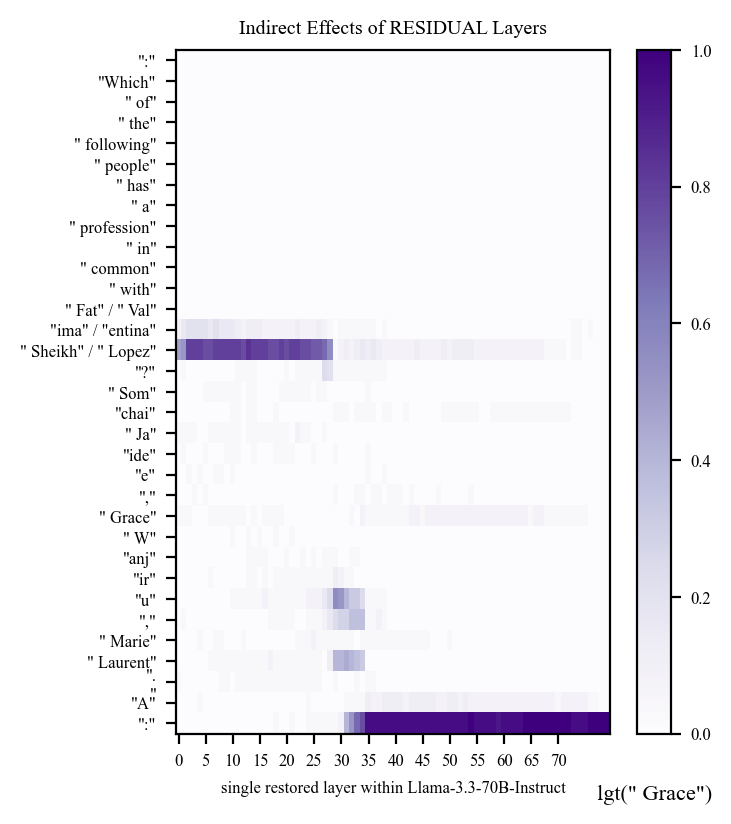

clean_subj_range=(14, 17)
patched_subj_range=(14, 17)
trace_start_idx=2
Decoded clean input: <|begin_of_text|>Q:Which of the following people has a profession in common with Valentina Lopez? Somchai Jaidee, Grace Wanjiru, Marie Laurent.
A:
Decoded patched input: <|begin_of_text|>Q:Which of the following people has a profession in common with Fatima Sheikh? Somchai Jaidee, Grace Wanjiru, Marie Laurent.
A:
===> trace_start_idx=2
2025-07-09 05:53:07 __main__ DEBUG    tracing answer for ['32171( Grace)']
2025-07-09 05:53:07 __main__ DEBUG    base_score=19.25 | base_indv_scores={32171: 19.25}
2025-07-09 05:53:07 __main__ DEBUG    low_score=16.125 | low_indv_scores={32171: 16.125}
2025-07-09 05:53:07 __main__ DEBUG    base_score=19.25 | low_score=16.125
2025-07-09 05:53:07 __main__ DEBUG    ---------- tracing important states | kind='attention' ----------


100%|██████████| 2640/2640 [06:33<00:00,  6.70it/s]

2025-07-09 05:59:41 __main__ INFO     base_score=19.25 | low_score=16.125
2025-07-09 05:59:41 __main__ INFO     trace_results=CausalTracingResult(patch_input_toks=['<|begin_of_text|>', 'Q', ':', 'Which', ' of', ' the', ' following', ' people', ' has', ' a', ' profession', ' in', ' common', ' with', ' Fat', 'ima', ' Sheikh', '?', ' Som', 'chai', ' Ja', 'ide', 'e', ',', ' Grace', ' W', 'anj', 'ir', 'u', ',', ' Marie', ' Laurent', '.\n', 'A', ':'], corrupt_input_toks=['<|begin_of_text|>', 'Q', ':', 'Which', ' of', ' the', ' following', ' people', ' has', ' a', ' profession', ' in', ' common', ' with', ' Val', 'entina', ' Lopez', '?', ' Som', 'chai', ' Ja', 'ide', 'e', ',', ' Grace', ' W', 'anj', 'ir', 'u', ',', ' Marie', ' Laurent', '.\n', 'A', ':'], trace_start_idx=2, answer=[PredictedToken(token=' Grace', prob=None, logit=19.25, token_id=32171, metadata=None)], low_score=16.125, base_score=19.25, indirect_effects=tensor([[0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
        [0

2025-07-09 05:59:41 matplotlib.colorbar DEBUG    locator: <matplotlib.ticker.AutoLocator object at 0x7fe9db469a90>
2025-07-09 05:59:41 matplotlib.axes._base DEBUG    title position was updated manually, not adjusting
2025-07-09 05:59:41 matplotlib.axes._base DEBUG    title position was updated manually, not adjusting
2025-07-09 05:59:41 matplotlib.axes._base DEBUG    title position was updated manually, not adjusting


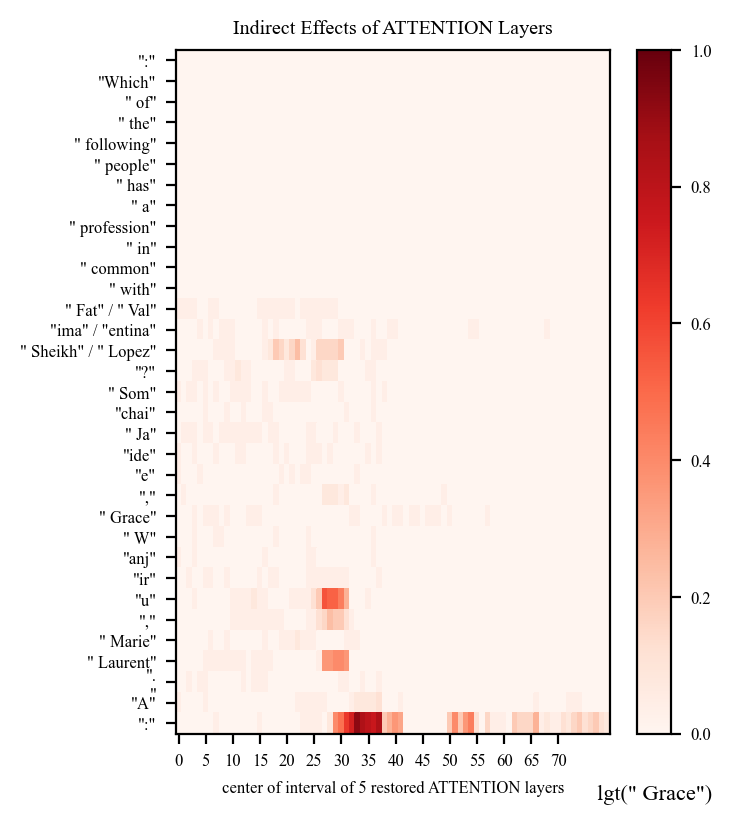

clean_subj_range=(14, 17)
patched_subj_range=(14, 17)
trace_start_idx=2
Decoded clean input: <|begin_of_text|>Q:Which of the following people has a profession in common with Valentina Lopez? Somchai Jaidee, Grace Wanjiru, Marie Laurent.
A:
Decoded patched input: <|begin_of_text|>Q:Which of the following people has a profession in common with Fatima Sheikh? Somchai Jaidee, Grace Wanjiru, Marie Laurent.
A:
===> trace_start_idx=2
2025-07-09 05:59:42 __main__ DEBUG    tracing answer for ['32171( Grace)']
2025-07-09 05:59:42 __main__ DEBUG    base_score=19.25 | base_indv_scores={32171: 19.25}
2025-07-09 05:59:42 __main__ DEBUG    low_score=16.125 | low_indv_scores={32171: 16.125}
2025-07-09 05:59:42 __main__ DEBUG    base_score=19.25 | low_score=16.125
2025-07-09 05:59:42 __main__ DEBUG    ---------- tracing important states | kind='mlp' ----------


100%|██████████| 2640/2640 [06:32<00:00,  6.73it/s]

2025-07-09 06:06:14 __main__ INFO     base_score=19.25 | low_score=16.125
2025-07-09 06:06:14 __main__ INFO     trace_results=CausalTracingResult(patch_input_toks=['<|begin_of_text|>', 'Q', ':', 'Which', ' of', ' the', ' following', ' people', ' has', ' a', ' profession', ' in', ' common', ' with', ' Fat', 'ima', ' Sheikh', '?', ' Som', 'chai', ' Ja', 'ide', 'e', ',', ' Grace', ' W', 'anj', 'ir', 'u', ',', ' Marie', ' Laurent', '.\n', 'A', ':'], corrupt_input_toks=['<|begin_of_text|>', 'Q', ':', 'Which', ' of', ' the', ' following', ' people', ' has', ' a', ' profession', ' in', ' common', ' with', ' Val', 'entina', ' Lopez', '?', ' Som', 'chai', ' Ja', 'ide', 'e', ',', ' Grace', ' W', 'anj', 'ir', 'u', ',', ' Marie', ' Laurent', '.\n', 'A', ':'], trace_start_idx=2, answer=[PredictedToken(token=' Grace', prob=None, logit=19.25, token_id=32171, metadata=None)], low_score=16.125, base_score=19.25, indirect_effects=tensor([[ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
    

2025-07-09 06:06:14 matplotlib.colorbar DEBUG    locator: <matplotlib.ticker.AutoLocator object at 0x7fe9d9b8e210>
2025-07-09 06:06:14 matplotlib.axes._base DEBUG    title position was updated manually, not adjusting
2025-07-09 06:06:14 matplotlib.axes._base DEBUG    title position was updated manually, not adjusting
2025-07-09 06:06:14 matplotlib.axes._base DEBUG    title position was updated manually, not adjusting


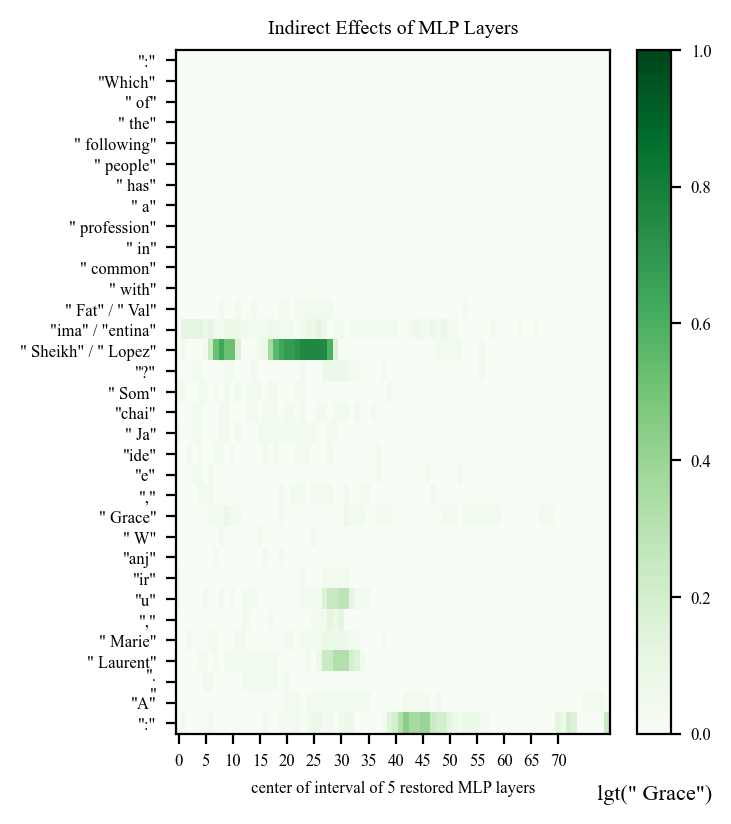

In [44]:
from src.plotting import plot_trace_heatmap

for kind in ["residual", "attention", "mlp"]:
    trace_results = trace_important_states(
        mt=mt,
        prompt_template=sample.prompt_template,
        clean_subj=sample.clean_entity,
        patched_subj=sample.patched_entity,
        common_entities=sample.common_entities,
        trace_start_marker="Q:",
        metric="logit",
        kind=kind,
        window_size=1 if kind == "residual" else 5,
        ans_tokens=sample.patched_answer_toks,
    )

    logger.info(f"{trace_results=}")

    plot_trace_heatmap(
        result=trace_results,
        model_name=model_key.split("/")[-1],
        scale_range=(0, 1) if trace_results.normalized is True else None,
    )

In [45]:
from tqdm.auto import tqdm
from src.functional import detensorize
import numpy as np

failed_samples = []

for idx, sample in tqdm(enumerate(samples)):
    logger.debug("-" * 50)
    logger.info(f"{idx+1}/{len(samples)} => {sample}")
    logger.debug(f"-" * 50)

    if sample.patched_entity is None:
        continue
    
    for kind in ["residual", "mlp", "attention"]:
        print(f"{sample.patched_entity=}")
        try:
            trace_results = trace_important_states(
                mt=mt,
                prompt_template=sample.prompt_template,
                clean_subj=sample.clean_entity,
                patched_subj=sample.patched_entity,
                common_entities=sample.common_entities,
                trace_start_marker="Q:",
                metric="logit",
                kind=kind,
                window_size=1 if kind == "residual" else 5,
                ans_tokens=sample.patched_answer_toks,
            )

            trace_results_dten = detensorize(trace_results)
            kind_save_dir = os.path.join(activation_patching_path, kind)
            os.makedirs(kind_save_dir, exist_ok=True)

            file_name = f"{idx+1:04d}_{sample.patched_entity} - {sample.clean_entity}.npz"
            np.savez_compressed(
                os.path.join(kind_save_dir, file_name),
                **trace_results_dten.__dict__,
                allow_pickle=True,
            )
        except AssertionError as e:
            logger.warning(f"AssertionError for sample {idx+1}, kind={kind}: {str(e)}")
            failed_samples.append({
                'index': idx + 1,
                'sample': sample,
                'kind': kind,
                'error': str(e)
            })
            continue
        except Exception as e:
            logger.error(f"Unexpected error for sample {idx+1}, kind={kind}: {type(e).__name__}: {str(e)}")
            failed_samples.append({
                'index': idx + 1,
                'sample': sample,
                'kind': kind,
                'error': f"{type(e).__name__}: {str(e)}"
            })
            continue

    logger.debug("-" * 50)

if failed_samples:
    logger.warning(f"\nTotal failed traces: {len(failed_samples)}")
    for failure in failed_samples:
        logger.warning(f"Sample {failure['index']} ({failure['sample'].clean_entity} -> {failure['sample'].patched_entity}), "
                      f"kind={failure['kind']}: {failure['error']}")

0it [00:00, ?it/s]

2025-07-09 06:26:48 __main__ DEBUG    --------------------------------------------------
2025-07-09 06:26:48 __main__ INFO     1/21 => ActivationPatchingChoiceSamples(prompt_template='Q:Which of the following people has a profession in common with {}? {}.\nA:', common_entities=['Somchai Jaidee', 'Grace Wanjiru', 'Marie Laurent'], clean_entity='Valentina Lopez', patched_entity='Fatima Sheikh', clean_answer=' None', patched_answer=' Grace', patched_answer_toks=[32171])
2025-07-09 06:26:48 __main__ DEBUG    --------------------------------------------------
sample.patched_entity='Fatima Sheikh'
clean_subj_range=(14, 17)
patched_subj_range=(14, 17)
trace_start_idx=2
Decoded clean input: <|begin_of_text|>Q:Which of the following people has a profession in common with Valentina Lopez? Somchai Jaidee, Grace Wanjiru, Marie Laurent.
A:
Decoded patched input: <|begin_of_text|>Q:Which of the following people has a profession in common with Fatima Sheikh? Somchai Jaidee, Grace Wanjiru, Marie Laure

100%|██████████| 2640/2640 [06:33<00:00,  6.71it/s]

2025-07-09 06:33:22 __main__ INFO     base_score=19.25 | low_score=16.125


sample.patched_entity='Fatima Sheikh'
clean_subj_range=(14, 17)
patched_subj_range=(14, 17)
trace_start_idx=2
Decoded clean input: <|begin_of_text|>Q:Which of the following people has a profession in common with Valentina Lopez? Somchai Jaidee, Grace Wanjiru, Marie Laurent.
A:
Decoded patched input: <|begin_of_text|>Q:Which of the following people has a profession in common with Fatima Sheikh? Somchai Jaidee, Grace Wanjiru, Marie Laurent.
A:
===> trace_start_idx=2
2025-07-09 06:33:22 __main__ DEBUG    tracing answer for ['32171( Grace)']
2025-07-09 06:33:23 __main__ DEBUG    base_score=19.25 | base_indv_scores={32171: 19.25}
2025-07-09 06:33:23 __main__ DEBUG    low_score=16.125 | low_indv_scores={32171: 16.125}
2025-07-09 06:33:23 __main__ DEBUG    base_score=19.25 | low_score=16.125
2025-07-09 06:33:23 __main__ DEBUG    ---------- tracing important states | kind='mlp' ----------


...

2025-07-09 12:05:54 __main__ INFO     base_score=16.625 | low_score=15.25


sample.patched_entity='Laura Fernandez'
clean_subj_range=(14, 17)
patched_subj_range=(14, 16)
trace_start_idx=2
Decoded clean input: <|begin_of_text|>Q:Which of the following people has a profession in common with João Silva? James Mwangi, Ivan Petrov, Fatima Sheikh.
A:
Decoded patched input: <|begin_of_text|>Q:Which of the following people has a profession in common with<|eot_id|> Laura Fernandez? James Mwangi, Ivan Petrov, Fatima Sheikh.
A:
===> trace_start_idx=2
2025-07-09 12:05:55 __main__ DEBUG    tracing answer for ['42521( Ivan)']
2025-07-09 12:05:55 __main__ DEBUG    base_score=16.625 | base_indv_scores={42521: 16.625}
2025-07-09 12:05:55 __main__ DEBUG    low_score=15.25 | low_indv_scores={42521: 15.25}
2025-07-09 12:05:55 __main__ DEBUG    base_score=16.625 | low_score=15.25
2025-07-09 12:05:55 __main__ DEBUG    ---------- tracing important states | kind='attention' ----------


100%|██████████| 2480/2480 [05:52<00:00,  7.04it/s]

2025-07-09 12:11:47 __main__ INFO     base_score=16.625 | low_score=15.25


2025-07-09 12:11:48 __main__ DEBUG    --------------------------------------------------
2025-07-09 12:11:48 __main__ WARNING  
Total failed traces: 9
2025-07-09 12:11:48 __main__ WARNING  Sample 3 (Amara Adeyemi -> Hans Mueller), kind=residual: low_score=15.875 | base_score=15.1875 >> low_score must be less than base_score
2025-07-09 12:11:48 __main__ WARNING  Sample 3 (Amara Adeyemi -> Hans Mueller), kind=mlp: low_score=15.875 | base_score=15.1875 >> low_score must be less than base_score
2025-07-09 12:11:48 __main__ WARNING  Sample 3 (Amara Adeyemi -> Hans Mueller), kind=attention: low_score=15.875 | base_score=15.1875 >> low_score must be less than base_score
2025-07-09 12:11:48 __main__ WARNING  Sample 7 (Amara Adeyemi -> Min-jun Park), kind=residual: low_score=16.5 | base_score=16.125 >> low_score must be less than base_score
2025-07-09 12:11:48 __main__ WARNING  Sample 7 (Amara Adeyemi -> Min-jun Park), kind=mlp: low_score=16.5 | base_score=16.125 >> low_score must be less than 

## Parse the results

In [46]:
from src.dataset import ActivationPatchingChoiceSamples

activation_patching_path = os.path.join(
    env_utils.DEFAULT_RESULTS_DIR,
    result_sub_dir, SYNTH_DATASET,
)
samples_path = os.path.join(
    activation_patching_path, f"profession/samples.json"
)

samples = []
with open(samples_path, "r") as f:
    samples = json.load(f)
samples = [ActivationPatchingChoiceSamples.from_dict(sample) for sample in samples]

In [47]:
#os.chdir("../")
os.getcwd()

'/disk/u/gio/mechinterp'

In [48]:
from src.trace import CausalTracingResult
import numpy as np

model_name = model_key.split("/")[-1]

target_attribute = "profession"

load_dir = os.path.join(
    "results", result_sub_dir, "test_72", target_attribute, "residual"
)

indirect_effects_collection = []
for file_name in os.listdir(load_dir):
    npz_file = np.load(os.path.join(load_dir, file_name), allow_pickle=True)
    indirect_effects_collection.append(CausalTracingResult.from_npz(npz_file))

In [49]:
from src.tokens import prepare_input, find_token_range
from src.models import ModelandTokenizer

def find_common_entity_range(mt, toks, common_entity):
    text = "".join(toks)
    inputs = prepare_input(
        prompts=text,
        tokenizer=mt,
        add_special_tokens=False,
        return_offsets_mapping=True,
    )
    rng = find_token_range(
        string=text,
        substring=common_entity,
        tokenizer=mt,
        offset_mapping=inputs["offset_mapping"][0],
        occurence=-1,
    )
    return rng

def get_token_ranges(
    mt: ModelandTokenizer,
    trace_res: CausalTracingResult,
    common_entities: list[str],
):
    common_entity_one_range_patch = find_common_entity_range(
        mt, trace_res.patch_input_toks, common_entities[0]
    )
    common_entity_two_range_patch = find_common_entity_range(
        mt, trace_res.patch_input_toks, common_entities[1]
    )
    common_entity_three_range_patch = find_common_entity_range(
        mt, trace_res.patch_input_toks, common_entities[2]
    )

    assert (
        trace_res.patch_input_toks[slice(*common_entity_one_range_patch)]
        == trace_res.corrupt_input_toks[slice(*common_entity_one_range_patch)]
    )
    assert (
        trace_res.patch_input_toks[slice(*common_entity_three_range_patch)]
        == trace_res.corrupt_input_toks[slice(*common_entity_three_range_patch)]
    )

    between_entities = (trace_res.subj_range[1], common_entity_one_range_patch[0])

    query_indices = (common_entity_three_range_patch[1], len(trace_res.patch_input_toks) - 2)

    subj_len = trace_res.subj_range[1] - trace_res.subj_range[0]
    #common_len = common_entity_range_patch[1] - common_entity_range_patch[0]
    
    return dict(
        previous=(trace_res.trace_start_idx, trace_res.subj_range[0]),
        subj_upto_2nd_last=(trace_res.subj_range[0], trace_res.subj_range[1] - 2)
        if subj_len > 2
        else None,
        subj_2nd_last=trace_res.subj_range[1] - 2 if subj_len >= 2 else None,
        subj_last=trace_res.subj_range[1] - 1,
        between_entities=between_entities,
        common_entity_one=common_entity_one_range_patch,
        common_entity_two=common_entity_two_range_patch,
        common_entity_three=common_entity_three_range_patch,
        query_indices=query_indices,
        second_last=-2,
        last=-1
    )

def get_categorized_indirect_effects(
    trace_res: CausalTracingResult, token_ranges: dict[str, int | tuple[int, int]]
):
    indirect_effects = {}
    for category in token_ranges:
        if token_ranges[category] is None:
            indirect_effects[category] = None
            continue
        if isinstance(token_ranges[category], int) == False:
            rng = token_ranges[category]
            rng = (
                rng[0] - trace_res.trace_start_idx,
                rng[1] - trace_res.trace_start_idx,
            )
            indirect_effects[category] = trace_res.indirect_effects[
                rng[0] : rng[1]
            ].mean(dim=0)
        else:
            idx = token_ranges[category]
            idx = idx - trace_res.trace_start_idx if idx > 0 else idx
            indirect_effects[category] = trace_res.indirect_effects[idx]

    return indirect_effects

def parse_common_entities(tokens):
    # find bounds
    try:
        start = tokens.index('?') + 1
        end   = tokens.index('.\n')
    except ValueError:
        raise ValueError("Can't find question mark or terminating period")

    # slice out the name-tokens, filter any special tokens
    name_toks = [
        t for t in tokens[start:end]
        if not (t.startswith('<') and t.endswith('>'))
    ]

    # stitch them into one string, split on commas, strip whitespace
    names_str = ''.join(name_toks)
    return [name.strip() for name in names_str.split(',') if name.strip()]

sample_idx = 0
trace_res = indirect_effects_collection[sample_idx]
start_idx = trace_res.trace_start_idx
common_entities = parse_common_entities(trace_res.patch_input_toks)
token_ranges = get_token_ranges(mt, trace_res, common_entities=common_entities)
categorized_effects = get_categorized_indirect_effects(trace_res, token_ranges)

In [50]:
categorized_effects

{'previous': tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0.], dtype=torch.float64),
 'subj_upto_2nd_last': tensor([-5.2941e-01, -5.6863e-01, -5.8824e-01, -6.2745e-01, -5.8824e-01,
         -5.4902e-01, -5.8824e-01, -5.8824e-01, -5.8824e-01, -6.0784e-01,
         -6.2745e-01, -5.8824e-01, -6.2745e-01, -5.6863e-01, -4.9020e-01,
         -4.9020e-01, -4.9020e-01, -4.9020e-01, -4.3137e-01, -2.9412e-01,
         -2.7451e-01, -3.1373e-01, -3.1373e-01, -2.7451e-01, -3.1373e-01,
         -2.9412e-01, -3.1373e-01, -2.5490e-01, -2.7451e-01, -3.3333e-01,
         -3.3333e-01, -3.1373e-01, -3.3333e-01, -2.7451e-01, -1.7647e-01,
         -1.1765e-01, -1.1765e-01, -9.8039e-02, -7.8431e-02, -7.8431e

In [51]:
from typing import Literal
from src.utils.typing import PredictedToken

def average_indirect_effects(
    categorized_effects: list[dict],
    kind: Literal["residual", "mlp", "attention"] = "residual",
    window: int = 1,
    metric: Literal["logit", "prob"] = "logit",
):
    aie = {
        k: torch.zeros_like(categorized_effects[0]["subj_last"])
        for k, v in categorized_effects[0].items()
    }
    for category in aie:
        category_count = 0
        for effects in categorized_effects:
            if effects[category] is not None:
                aie[category] += effects[category]
                category_count += 1
        if category_count > 0:
            aie[category] /= category_count

    return CausalTracingResult(
        patch_input_toks=list(aie.keys()),
        corrupt_input_toks=list(aie.keys()),
        indirect_effects=torch.stack(list(aie.values())),
        trace_start_idx=0,
        answer=[PredictedToken(token="Ans", prob=1.0, logit=10.0)],
        low_score=0.0,
        base_score=1.0,
        subj_range=(1, 4),
        normalized=True,
        kind=kind,
        window=window,
        metric=metric,
    )

aie = average_indirect_effects(categorized_effects=[categorized_effects])

In [52]:
aie

CausalTracingResult(patch_input_toks=['previous', 'subj_upto_2nd_last', 'subj_2nd_last', 'subj_last', 'between_entities', 'common_entity_one', 'common_entity_two', 'common_entity_three', 'query_indices', 'second_last', 'last'], corrupt_input_toks=['previous', 'subj_upto_2nd_last', 'subj_2nd_last', 'subj_last', 'between_entities', 'common_entity_one', 'common_entity_two', 'common_entity_three', 'query_indices', 'second_last', 'last'], trace_start_idx=0, answer=[PredictedToken(token='Ans', prob=1.0, logit=10.0, token_id=None, metadata=None)], low_score=0.0, base_score=1.0, indirect_effects=tensor([[ 0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
          0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
          0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
          0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
          0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
          0.0000e+00,  0.0000e+00, 

In [53]:
from tqdm.auto import tqdm
from src.functional import detensorize
import numpy as np

# This code generates the .npz files that are currently missing
for idx, sample in tqdm(enumerate(samples)):
    logger.debug("-" * 50)
    logger.info(f"{idx+1}/{len(samples)} => {sample}")
    logger.debug("-" * 50)

    for kind in ["residual", "mlp", "attention"]:
        trace_results = trace_important_states(
            mt=mt,
            prompt_template=sample.prompt_template,
            clean_subj=sample.clean_entity,
            patched_subj=sample.patched_entity,
            common_entities=sample.common_entities,
            trace_start_marker="Q:",
            metric="logit",
            kind=kind,
            window_size=1 if kind == "residual" else 5,
            ans_tokens=sample.patched_answer_toks,
        )
        
        trace_results_dten = detensorize(trace_results)
        kind_save_dir = os.path.join(
            "results", "activation_patching", "test_72", target_attribute, kind
        )
        os.makedirs(kind_save_dir, exist_ok=True)

        file_name = f"{idx+1:04d}_{sample.patched_entity} - {sample.clean_entity}.npz"
        np.savez_compressed(
            os.path.join(kind_save_dir, file_name),
            **trace_results_dten.__dict__,
            allow_pickle=True,
        )

    logger.debug("-" * 50)

0it [00:00, ?it/s]

2025-07-09 13:35:05 __main__ DEBUG    --------------------------------------------------
2025-07-09 13:35:05 __main__ INFO     1/21 => ActivationPatchingChoiceSamples(prompt_template='Q:Which of the following people has a profession in common with {}? {}.\nA:', common_entities=['Somchai Jaidee', 'Grace Wanjiru', 'Marie Laurent'], clean_entity='Valentina Lopez', patched_entity='Fatima Sheikh', clean_answer=' None', patched_answer=' Grace', patched_answer_toks=[32171])
2025-07-09 13:35:05 __main__ DEBUG    --------------------------------------------------


clean_subj_range=(14, 17)
patched_subj_range=(14, 17)
trace_start_idx=2
Decoded clean input: <|begin_of_text|>Q:Which of the following people has a profession in common with Valentina Lopez? Somchai Jaidee, Grace Wanjiru, Marie Laurent.
A:
Decoded patched input: <|begin_of_text|>Q:Which of the following people has a profession in common with Fatima Sheikh? Somchai Jaidee, Grace Wanjiru, Marie Laurent.
A:
===> trace_start_idx=2
2025-07-09 13:35:05 __main__ DEBUG    tracing answer for ['32171( Grace)']
2025-07-09 13:35:06 __main__ DEBUG    base_score=19.25 | base_indv_scores={32171: 19.25}
2025-07-09 13:35:06 __main__ DEBUG    low_score=16.125 | low_indv_scores={32171: 16.125}
2025-07-09 13:35:06 __main__ DEBUG    base_score=19.25 | low_score=16.125
2025-07-09 13:35:06 __main__ DEBUG    ---------- tracing important states | kind='residual' ----------


  1%|          | 32/2640 [00:04<06:15,  6.94it/s]


KeyboardInterrupt: 

2025-07-09 13:35:15 __main__ INFO     (1/21) ActivationPatchingChoiceSamples(prompt_template='Q:Which of the following people has a profession in common with {}? {}.\nA:', common_entities=['Somchai Jaidee', 'Grace Wanjiru', 'Marie Laurent'], clean_entity='Valentina Lopez', patched_entity='Fatima Sheikh', clean_answer=' None', patched_answer=' Grace', patched_answer_toks=[32171])
2025-07-09 13:35:15 __main__ INFO     (2/21) ActivationPatchingChoiceSamples(prompt_template='Q:Which of the following people has a profession in common with {}? {}.\nA:', common_entities=['Jose Cruz', 'Nguyen Van Duc', 'Erik Andersson'], clean_entity='Yuki Tanaka', patched_entity='Chinedu Okafor', clean_answer=' None', patched_answer=' Nguyen', patched_answer_toks=[64261])
2025-07-09 13:35:15 __main__ INFO     (3/21) ActivationPatchingChoiceSamples(prompt_template='Q:Which of the following people has a profession in common with {}? {}.\nA:', common_entities=['Jennifer Davis', 'Ayse Kaya', 'Jose Cruz'], clean_e

2025-07-09 13:35:15 __main__ INFO     (9/21) ActivationPatchingChoiceSamples(prompt_template='Q:Which of the following people has a profession in common with {}? {}.\nA:', common_entities=['Min-jun Park', 'Michael Johnson', 'João Silva'], clean_entity='Takeshi Yamamoto', patched_entity='Diego Martinez', clean_answer=' None', patched_answer=' Michael', patched_answer_toks=[8096])
2025-07-09 13:35:15 __main__ INFO     (10/21) ActivationPatchingChoiceSamples(prompt_template='Q:Which of the following people has a profession in common with {}? {}.\nA:', common_entities=['Nguyen Van Duc', 'Natasha Ivanova', 'David Cohen'], clean_entity='Chinedu Okafor', patched_entity='Valentina Lopez', clean_answer=' None', patched_answer=' Natasha', patched_answer_toks=[87766])
2025-07-09 13:35:15 __main__ INFO     (11/21) ActivationPatchingChoiceSamples(prompt_template='Q:Which of the following people has a profession in common with {}? {}.\nA:', common_entities=['Katarzyna Nowak', 'Rachel Levy', 'Astrid 

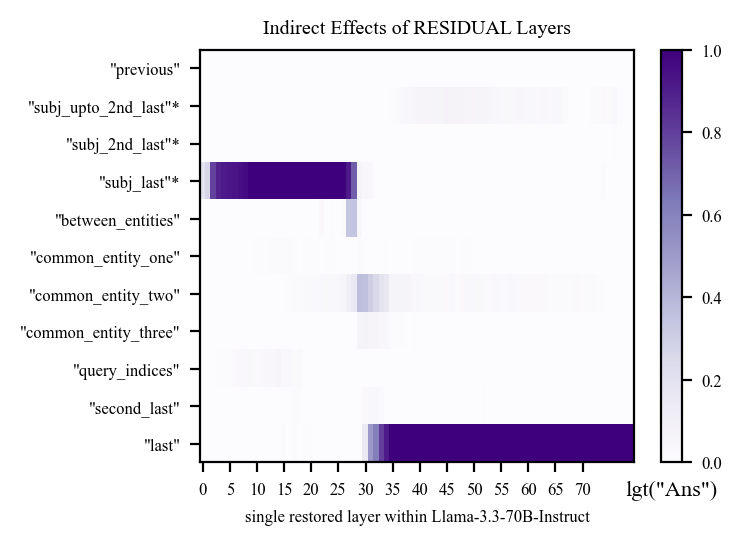

2025-07-09 13:35:15 __main__ INFO     (1/21) ActivationPatchingChoiceSamples(prompt_template='Q:Which of the following people has a profession in common with {}? {}.\nA:', common_entities=['Somchai Jaidee', 'Grace Wanjiru', 'Marie Laurent'], clean_entity='Valentina Lopez', patched_entity='Fatima Sheikh', clean_answer=' None', patched_answer=' Grace', patched_answer_toks=[32171])
2025-07-09 13:35:15 __main__ INFO     (2/21) ActivationPatchingChoiceSamples(prompt_template='Q:Which of the following people has a profession in common with {}? {}.\nA:', common_entities=['Jose Cruz', 'Nguyen Van Duc', 'Erik Andersson'], clean_entity='Yuki Tanaka', patched_entity='Chinedu Okafor', clean_answer=' None', patched_answer=' Nguyen', patched_answer_toks=[64261])
2025-07-09 13:35:15 __main__ INFO     (3/21) ActivationPatchingChoiceSamples(prompt_template='Q:Which of the following people has a profession in common with {}? {}.\nA:', common_entities=['Jennifer Davis', 'Ayse Kaya', 'Jose Cruz'], clean_e

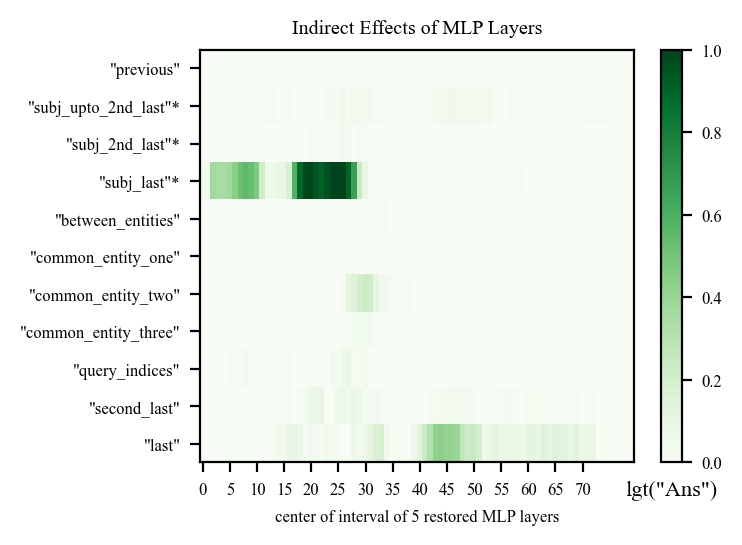

2025-07-09 13:35:16 __main__ INFO     (1/21) ActivationPatchingChoiceSamples(prompt_template='Q:Which of the following people has a profession in common with {}? {}.\nA:', common_entities=['Somchai Jaidee', 'Grace Wanjiru', 'Marie Laurent'], clean_entity='Valentina Lopez', patched_entity='Fatima Sheikh', clean_answer=' None', patched_answer=' Grace', patched_answer_toks=[32171])
2025-07-09 13:35:16 __main__ INFO     (2/21) ActivationPatchingChoiceSamples(prompt_template='Q:Which of the following people has a profession in common with {}? {}.\nA:', common_entities=['Jose Cruz', 'Nguyen Van Duc', 'Erik Andersson'], clean_entity='Yuki Tanaka', patched_entity='Chinedu Okafor', clean_answer=' None', patched_answer=' Nguyen', patched_answer_toks=[64261])
2025-07-09 13:35:16 __main__ INFO     (3/21) ActivationPatchingChoiceSamples(prompt_template='Q:Which of the following people has a profession in common with {}? {}.\nA:', common_entities=['Jennifer Davis', 'Ayse Kaya', 'Jose Cruz'], clean_e

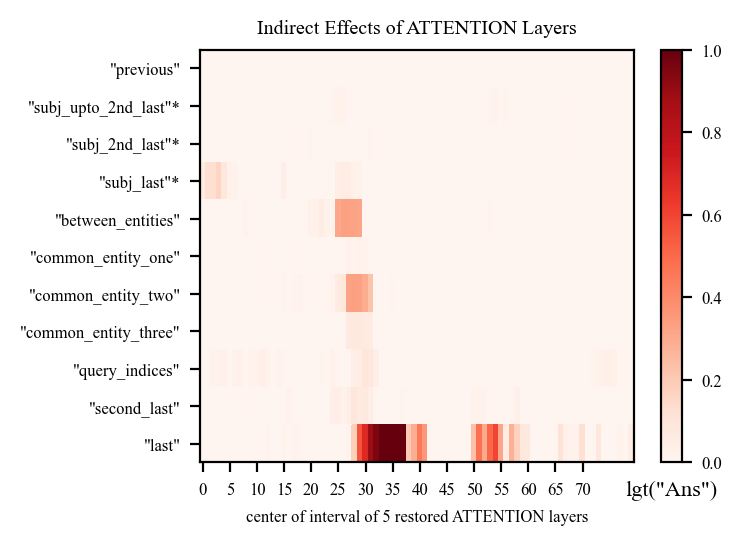

In [54]:
from src.plotting import plot_trace_heatmap

for kind in ["residual", "mlp", "attention"]:
    look_dir = os.path.join(
        "results", result_sub_dir, "test_72", target_attribute, kind
    )

    categorized_effects = []
    window, metric = None, None
    for idx, sample in enumerate(samples):
        logger.info(f"({idx + 1}/{len(samples)}) {sample}")

        file_name = f"{idx+1:04d}_{sample.patched_entity} - {sample.clean_entity}.npz"
        if file_name not in os.listdir(look_dir):
            logger.warning(f"Skipping {file_name}")
            continue

        trace_res = CausalTracingResult.from_npz(os.path.join(look_dir, file_name))
        window = trace_res.window
        metric = trace_res.metric
        token_ranges = get_token_ranges(mt, trace_res, common_entities=sample.common_entities)
        categorized_effects.append(
            get_categorized_indirect_effects(trace_res, token_ranges)
        )
    
    aie = average_indirect_effects(
        categorized_effects=categorized_effects,
        kind=kind,
        window=window,
        metric=metric
    )

    plot_trace_heatmap(
        result=aie,
        model_name=model_name,
        scale_range=(0, 1) if aie.normalized == True else None,
    )

clean_subj_range=(13, 15)
(13, 15)
trace_start_idx=2
Decoded clean input: <|begin_of_text|>Q:Which of the following people has something in common with Isaac Newton? Brad Pitt, Albert Einstein, Michael Jordan.
A:
Decoded patched input: <|begin_of_text|>Q:Which of the following people has something in common with Kobe Bryant? Brad Pitt, Albert Einstein, Michael Jordan.
A:
===> trace_start_idx=2
2025-07-04 07:51:02 src.trace DEBUG    tracing answer for ['8096( Michael)', '17527( Jordan)']
2025-07-04 07:51:04 src.trace DEBUG    base_score=13.0 | base_indv_scores={8096: 17.5, 17527: 8.5625}
2025-07-04 07:51:05 src.trace DEBUG    low_score=10.6875 | low_indv_scores={8096: 15.25, 17527: 6.15625}
2025-07-04 07:51:05 src.trace DEBUG    base_score=13.0 | low_score=10.6875
2025-07-04 07:51:05 src.trace DEBUG    ---------- tracing important states | kind='residual' ----------


100%|██████████| 2000/2000 [41:30<00:00,  1.25s/it]

2025-07-04 08:32:36 src.trace INFO     base_score=13.0 | low_score=10.6875
2025-07-04 08:32:36 __main__ INFO     trace_results=CausalTracingResult(patch_input_toks=['<|begin_of_text|>', 'Q', ':', 'Which', ' of', ' the', ' following', ' people', ' has', ' something', ' in', ' common', ' with', ' Kobe', ' Bryant', '?', ' Brad', ' Pitt', ',', ' Albert', ' Einstein', ',', ' Michael', ' Jordan', '.\n', 'A', ':'], corrupt_input_toks=['<|begin_of_text|>', 'Q', ':', 'Which', ' of', ' the', ' following', ' people', ' has', ' something', ' in', ' common', ' with', ' Isaac', ' Newton', '?', ' Brad', ' Pitt', ',', ' Albert', ' Einstein', ',', ' Michael', ' Jordan', '.\n', 'A', ':'], trace_start_idx=2, answer=[PredictedToken(token=' Michael', prob=None, logit=17.5, token_id=8096, metadata=None), PredictedToken(token=' Jordan', prob=None, logit=8.5625, token_id=17527, metadata=None)], low_score=10.6875, base_score=13.0, indirect_effects=tensor([[0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],

2025-07-04 08:32:36 matplotlib.font_manager DEBUG    findfont: score(FontEntry(fname='/usr/share/texmf/fonts/opentype/public/lm/lmromancaps10-regular.otf', name='Latin Modern Roman Caps', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 10.05
2025-07-04 08:32:36 matplotlib.font_manager DEBUG    findfont: score(FontEntry(fname='/usr/share/fonts/truetype/adf/GilliusADFNo2-BoldItalic.otf', name='Gillius ADF No2', style='italic', variant='normal', weight=700, stretch='normal', size='scalable')) = 11.335
2025-07-04 08:32:36 matplotlib.font_manager DEBUG    findfont: score(FontEntry(fname='/usr/share/texmf/fonts/opentype/public/tex-gyre/texgyrechorus-mediumitalic.otf', name='TeX Gyre Chorus', style='normal', variant='normal', weight=500, stretch='normal', size='scalable')) = 10.145
2025-07-04 08:32:36 matplotlib.font_manager DEBUG    findfont: score(FontEntry(fname='/usr/share/fonts/truetype/tlwg/Garuda-Bold.ttf', name='Garuda', style='normal', variant='nor

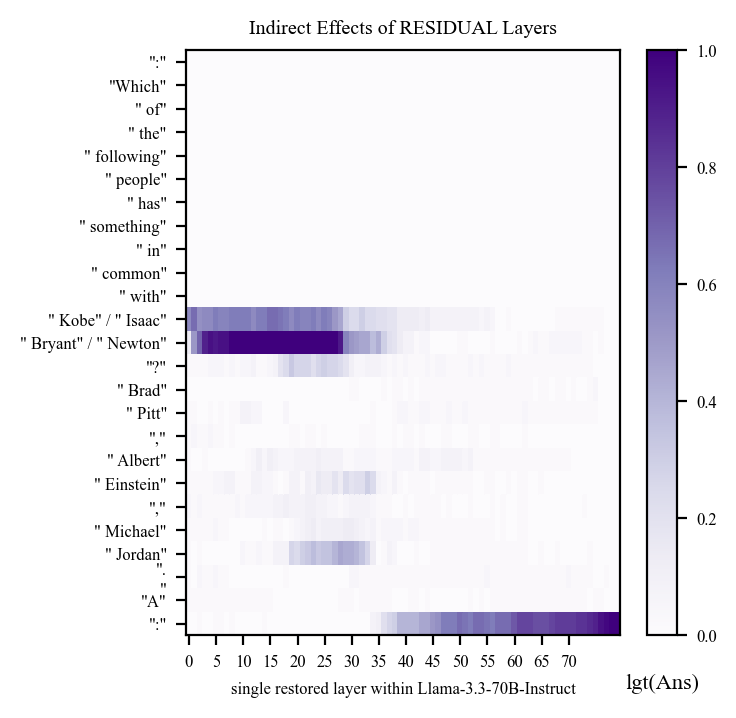

clean_subj_range=(13, 15)
(13, 15)
trace_start_idx=2
Decoded clean input: <|begin_of_text|>Q:Which of the following people has something in common with Isaac Newton? Brad Pitt, Albert Einstein, Michael Jordan.
A:
Decoded patched input: <|begin_of_text|>Q:Which of the following people has something in common with Kobe Bryant? Brad Pitt, Albert Einstein, Michael Jordan.
A:
===> trace_start_idx=2
2025-07-04 08:32:38 src.trace DEBUG    tracing answer for ['8096( Michael)', '17527( Jordan)']
2025-07-04 08:32:40 src.trace DEBUG    base_score=13.0 | base_indv_scores={8096: 17.5, 17527: 8.5625}
2025-07-04 08:32:41 src.trace DEBUG    low_score=10.6875 | low_indv_scores={8096: 15.25, 17527: 6.15625}
2025-07-04 08:32:41 src.trace DEBUG    base_score=13.0 | low_score=10.6875
2025-07-04 08:32:41 src.trace DEBUG    ---------- tracing important states | kind='attention' ----------


100%|██████████| 2000/2000 [41:31<00:00,  1.25s/it]

2025-07-04 09:14:12 src.trace INFO     base_score=13.0 | low_score=10.6875
2025-07-04 09:14:12 __main__ INFO     trace_results=CausalTracingResult(patch_input_toks=['<|begin_of_text|>', 'Q', ':', 'Which', ' of', ' the', ' following', ' people', ' has', ' something', ' in', ' common', ' with', ' Kobe', ' Bryant', '?', ' Brad', ' Pitt', ',', ' Albert', ' Einstein', ',', ' Michael', ' Jordan', '.\n', 'A', ':'], corrupt_input_toks=['<|begin_of_text|>', 'Q', ':', 'Which', ' of', ' the', ' following', ' people', ' has', ' something', ' in', ' common', ' with', ' Isaac', ' Newton', '?', ' Brad', ' Pitt', ',', ' Albert', ' Einstein', ',', ' Michael', ' Jordan', '.\n', 'A', ':'], trace_start_idx=2, answer=[PredictedToken(token=' Michael', prob=None, logit=17.5, token_id=8096, metadata=None), PredictedToken(token=' Jordan', prob=None, logit=8.5625, token_id=17527, metadata=None)], low_score=10.6875, base_score=13.0, indirect_effects=tensor([[0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],

2025-07-04 09:14:13 matplotlib.axes._base DEBUG    title position was updated manually, not adjusting


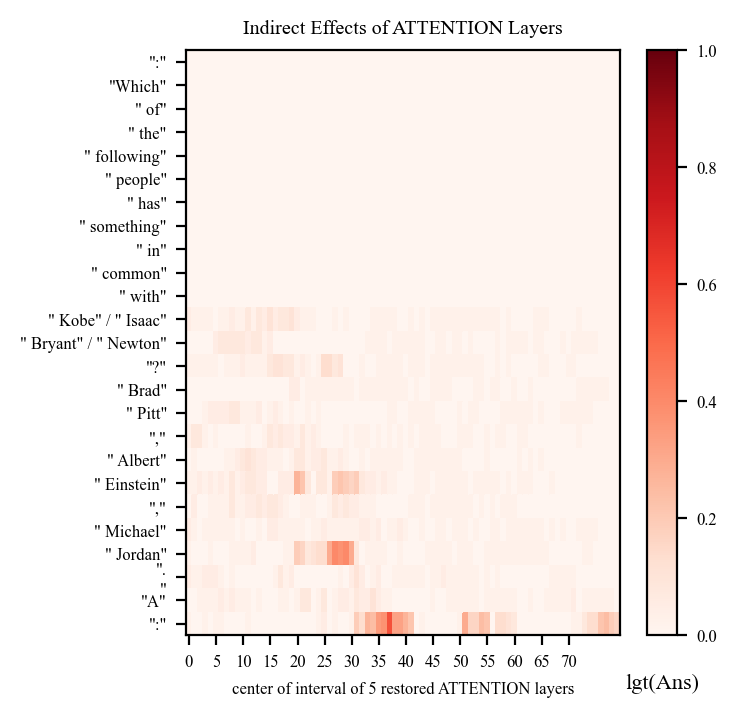

clean_subj_range=(13, 15)
(13, 15)
trace_start_idx=2
Decoded clean input: <|begin_of_text|>Q:Which of the following people has something in common with Isaac Newton? Brad Pitt, Albert Einstein, Michael Jordan.
A:
Decoded patched input: <|begin_of_text|>Q:Which of the following people has something in common with Kobe Bryant? Brad Pitt, Albert Einstein, Michael Jordan.
A:
===> trace_start_idx=2
2025-07-04 09:14:13 src.trace DEBUG    tracing answer for ['8096( Michael)', '17527( Jordan)']
2025-07-04 09:14:15 src.trace DEBUG    base_score=13.0 | base_indv_scores={8096: 17.5, 17527: 8.5625}
2025-07-04 09:14:17 src.trace DEBUG    low_score=10.6875 | low_indv_scores={8096: 15.25, 17527: 6.15625}
2025-07-04 09:14:17 src.trace DEBUG    base_score=13.0 | low_score=10.6875
2025-07-04 09:14:17 src.trace DEBUG    ---------- tracing important states | kind='mlp' ----------


100%|██████████| 2000/2000 [41:31<00:00,  1.25s/it]

2025-07-04 09:55:49 src.trace INFO     base_score=13.0 | low_score=10.6875
2025-07-04 09:55:49 __main__ INFO     trace_results=CausalTracingResult(patch_input_toks=['<|begin_of_text|>', 'Q', ':', 'Which', ' of', ' the', ' following', ' people', ' has', ' something', ' in', ' common', ' with', ' Kobe', ' Bryant', '?', ' Brad', ' Pitt', ',', ' Albert', ' Einstein', ',', ' Michael', ' Jordan', '.\n', 'A', ':'], corrupt_input_toks=['<|begin_of_text|>', 'Q', ':', 'Which', ' of', ' the', ' following', ' people', ' has', ' something', ' in', ' common', ' with', ' Isaac', ' Newton', '?', ' Brad', ' Pitt', ',', ' Albert', ' Einstein', ',', ' Michael', ' Jordan', '.\n', 'A', ':'], trace_start_idx=2, answer=[PredictedToken(token=' Michael', prob=None, logit=17.5, token_id=8096, metadata=None), PredictedToken(token=' Jordan', prob=None, logit=8.5625, token_id=17527, metadata=None)], low_score=10.6875, base_score=13.0, indirect_effects=tensor([[0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],

2025-07-04 09:55:49 matplotlib.axes._base DEBUG    title position was updated manually, not adjusting


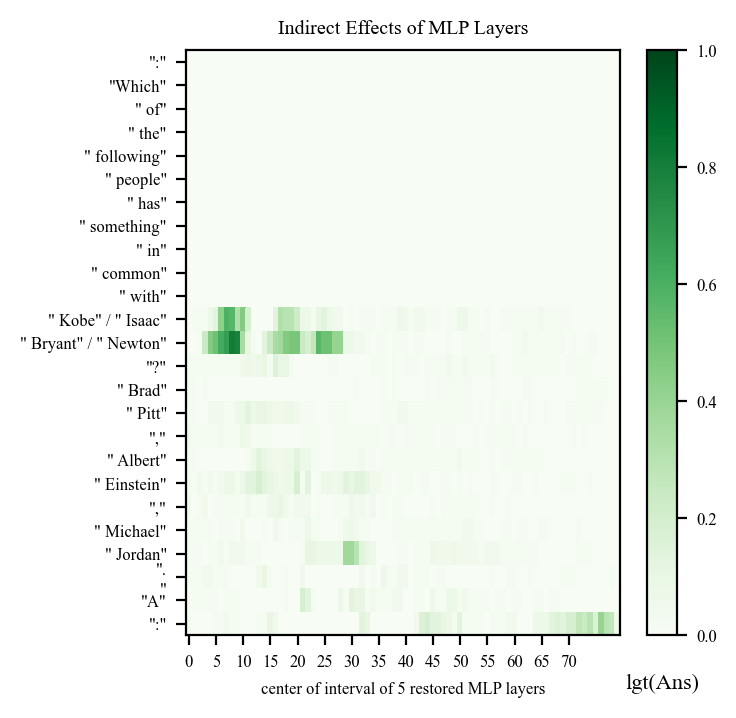

In [41]:
from src.trace import trace_important_states
from src.plotting import plot_trace_heatmap

for kind in ["residual", "attention", "mlp"]:
    trace_results = trace_important_states(
        mt=mt,
        prompt_template=sample.prompt_template,
        clean_subj=sample.clean_entity,
        patched_subj=sample.patched_entity,
        trace_start_marker="Q:",
        metric="logit",
        kind=kind,
        window_size=1 if kind == "residual" else 5,
        ans_tokens=sample.patched_answer_toks,
    )

    logger.info(f"{trace_results=}")

    plot_trace_heatmap(
        result=trace_results,
        model_name=model_key.split("/")[-1],
        scale_range=(0, 1) if trace_results.normalized is True else None,
    )

In [ ]:
from src.dataset import ActivationPatchingChoiceSamples

common_entities = ["Brad Pitt", "Albert Einstein", "Michael Jordan"]
clean_entity = "Isaac Newton"
patched_entity = "Kobe Bryant"
connection = "Albert Einstein"
clean_answer = "Albert Einstein"
patched_answer = " Michael Jordan"

prompt_template = f"""Q:Which of the following people has something in common with {subject_int}? {(", ").join(subject_set)}.
A:"""

patching_samples = []

patching_samples.append(ActivationPatchingChoiceSamples(
    prompt_template=prompt_template,
    common_entities=common_entities,
    clean_entity=clean_entity,
    patched_entity=connection,
    clean_answer=clean_answer,
    patched_answer=patched_answer,
    patched_answer_toks=mt.tokenizer.encode(patched_answer, add_special_tokens=False),
    )
)

patching_samples

[ActivationPatchingChoiceSamples(prompt_template='Q:Which of the following people has something in common with Isaac Newton? Brad Pitt, Albert Einstein, Michael Jordan.\nA:', common_entities=['Brad Pitt', 'Albert Einstein', 'Michael Jordan'], clean_entity='Isaac Newton', patched_entity='Albert Einstein', clean_answer='Albert Einstein', patched_answer=' Michael Jordan', patched_answer_toks=[8096, 17527])]